In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [5]:
# Load the dataset
feature_cols = [
    "PM2.5","PM10","NO2","CO","O3","SO2","Benzene",
    "month","day_of_week","season","quarter",
    "AQI_lag_1","AQI_lag_3","AQI_lag_7",
    "AQI_rolling_3","AQI_rolling_7","AQI_rolling_30"
]

df = pd.read_csv("city_day_clean.csv", parse_dates=["Date"])

train_df = df[df["Date"] < "2020-01-01"]
test_df  = df[df["Date"] >= "2020-01-01"]

X_train, y_train = train_df[feature_cols], train_df["AQI"]
X_test,  y_test  = test_df[feature_cols],  test_df["AQI"]

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (9911, 17) | Test: (1815, 17)


In [6]:
#  Evaluate function
results = []

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name:25s} → RMSE: {rmse:.2f}  MAE: {mae:.2f}  R²: {r2:.4f}")
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    return y_pred

In [7]:
#  Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = evaluate("Linear Regression", y_test, lr.predict(X_test))


Linear Regression         → RMSE: 18.77  MAE: 11.70  R²: 0.9268


In [8]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = evaluate("Random Forest", y_test, rf.predict(X_test))


Random Forest             → RMSE: 17.32  MAE: 10.32  R²: 0.9376


In [9]:
#  XGBoost
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    n_jobs=-1, verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
xgb_preds = evaluate("XGBoost", y_test, xgb.predict(X_test))

[0]	validation_0-rmse:91.81857
[100]	validation_0-rmse:16.85615
[200]	validation_0-rmse:16.59023
[300]	validation_0-rmse:16.55197
[400]	validation_0-rmse:16.57816
[499]	validation_0-rmse:16.63529

XGBoost                   → RMSE: 16.64  MAE: 10.05  R²: 0.9425


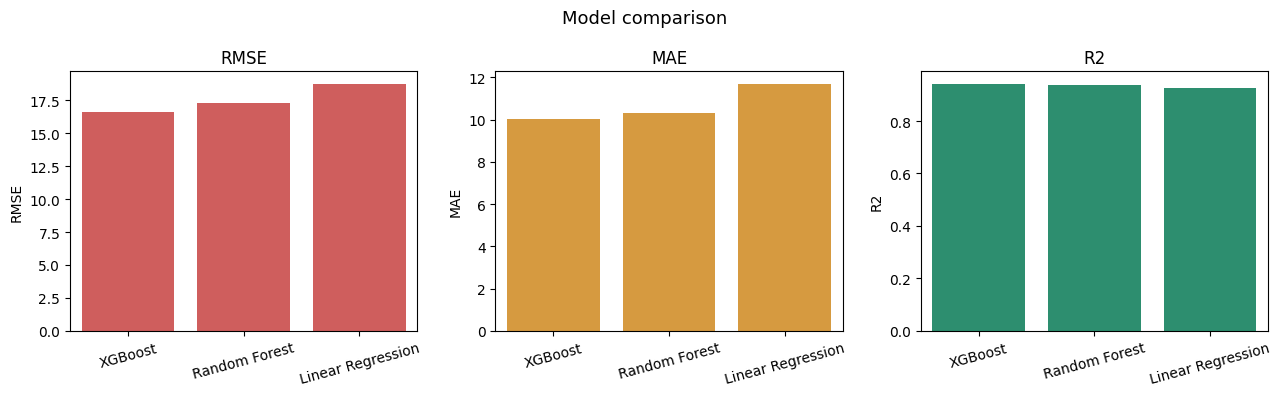

            Model      RMSE       MAE       R2
          XGBoost 16.635294 10.045090 0.942459
    Random Forest 17.320370 10.316742 0.937623
Linear Regression 18.768655 11.704596 0.926755


In [10]:
# Compare models visually
results_df = pd.DataFrame(results).sort_values("RMSE")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, color in zip(axes, ["RMSE","MAE","R2"], ["#E24B4A","#EF9F27","#1D9E75"]):
    sns.barplot(data=results_df, x="Model", y=metric, ax=ax, color=color)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Model comparison", fontsize=13)
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

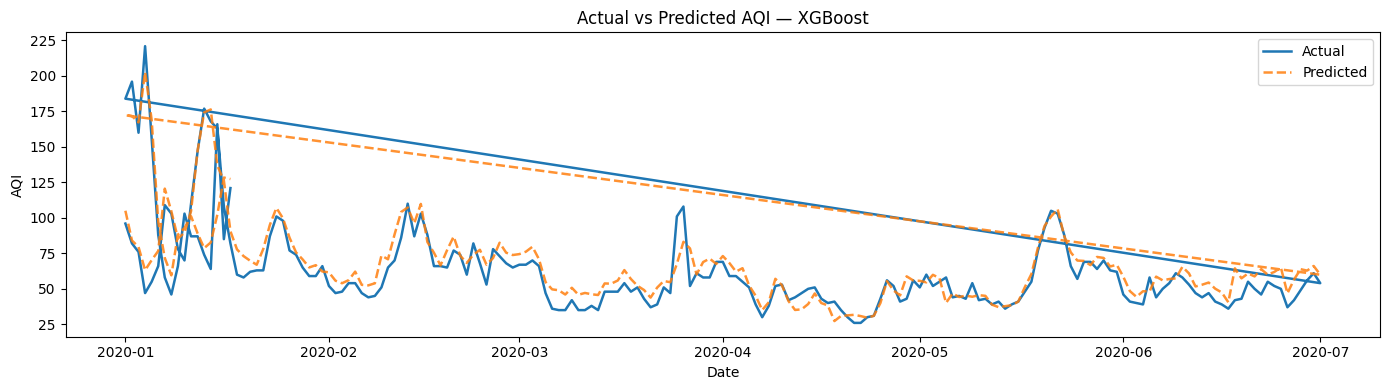

In [11]:
#  Actual vs Predicted plot
plt.figure(figsize=(14, 4))
sample = test_df.head(200)
plt.plot(sample["Date"].values, y_test.values[:200], label="Actual",    linewidth=1.8)
plt.plot(sample["Date"].values, xgb_preds[:200],     label="Predicted", linewidth=1.8, linestyle="--", alpha=0.85)
plt.title("Actual vs Predicted AQI — XGBoost")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

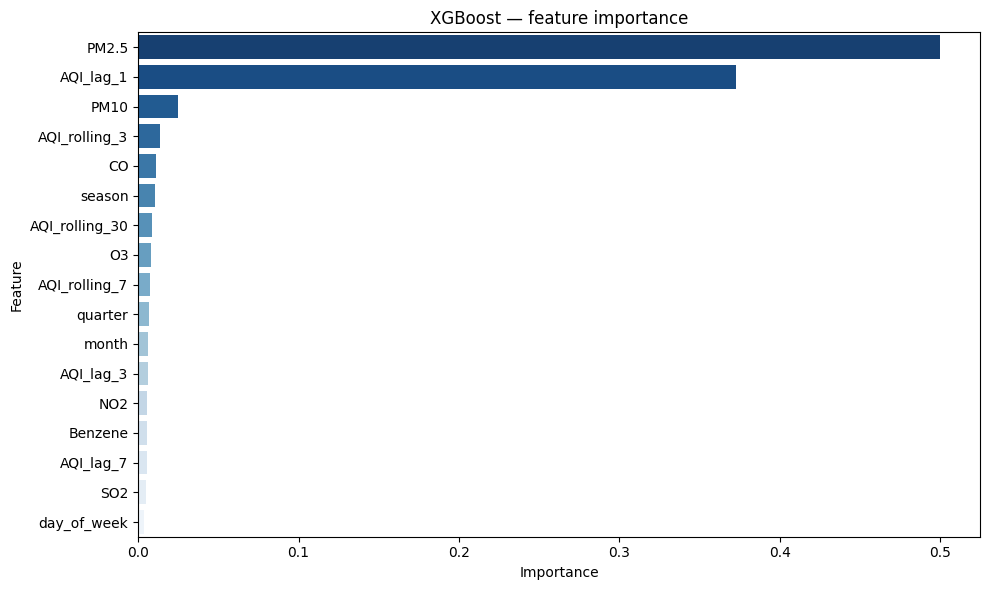

       Feature  Importance
         PM2.5    0.499982
     AQI_lag_1    0.373117
          PM10    0.024768
 AQI_rolling_3    0.013394
            CO    0.011102
        season    0.010370
AQI_rolling_30    0.008388
            O3    0.008152
 AQI_rolling_7    0.007599
       quarter    0.006536
         month    0.005976
     AQI_lag_3    0.005936
           NO2    0.005435
       Benzene    0.005293
     AQI_lag_7    0.005210
           SO2    0.004799
   day_of_week    0.003943


In [12]:
#  Feature importance
feat_imp = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="Blues_r")
plt.title("XGBoost — feature importance")
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

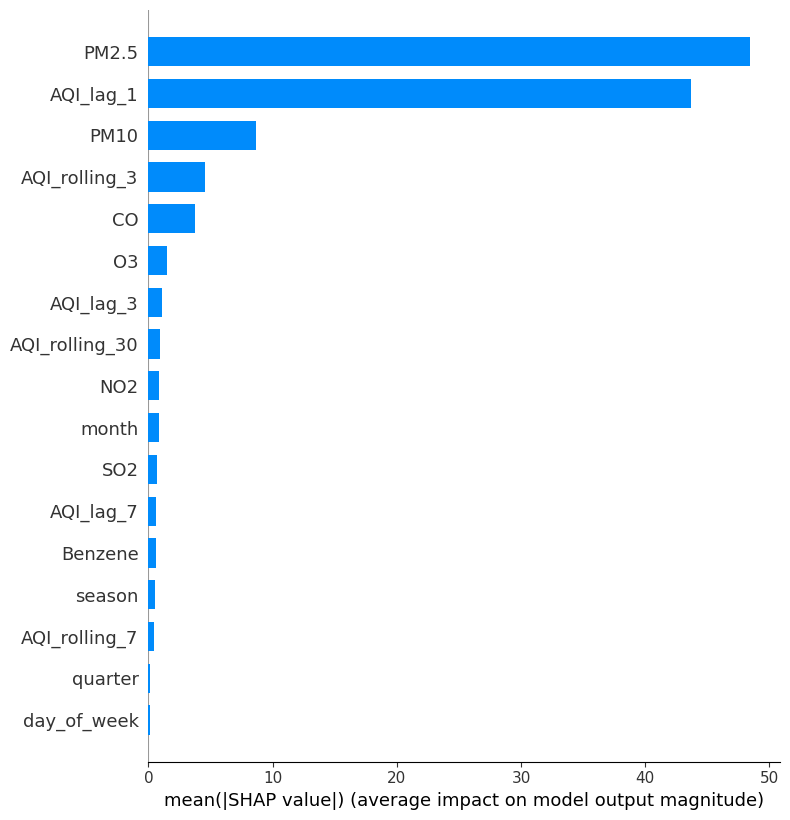

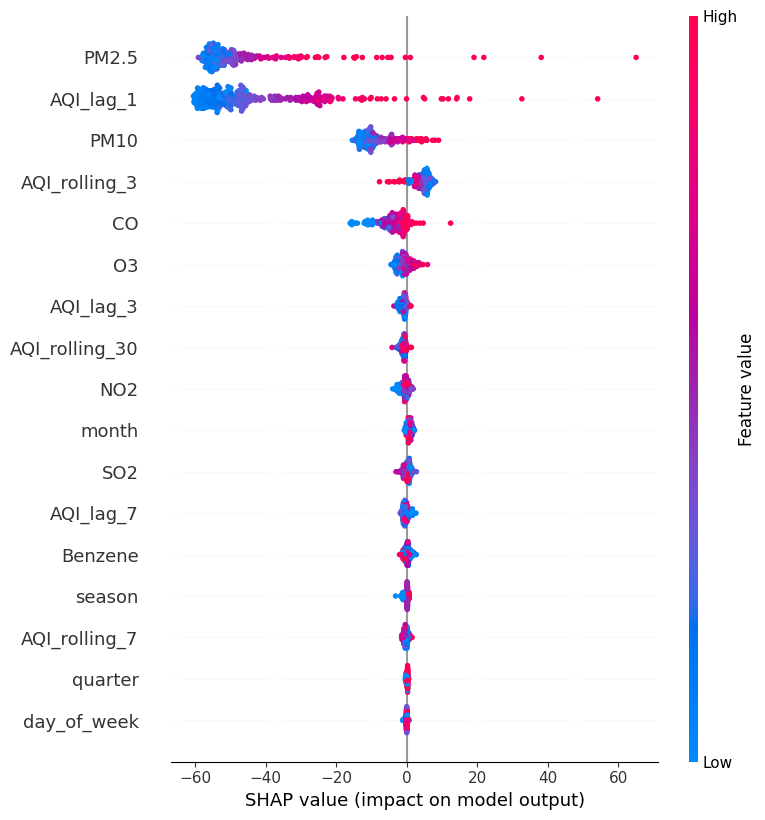

In [15]:
# SHAP (bonus — very impressive)
import shap

explainer = shap.TreeExplainer(xgb)
shap_vals = explainer.shap_values(X_test.iloc[:300])

plt.figure()
shap.summary_plot(shap_vals, X_test.iloc[:300], plot_type="bar")

plt.figure()
shap.summary_plot(shap_vals, X_test.iloc[:300])


In [16]:
#  Save model
joblib.dump(xgb, "xgb_aqi_model.pkl")
print("Model saved!")
print("Size:", round(__import__('os').path.getsize("xgb_aqi_model.pkl")/1024, 1), "KB")

Model saved!
Size: 2040.7 KB
